In [5]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
import aplpy
import astropy.wcs.wcs as wcs
import pandas as pd

from create_figs import create_sub_fig

In [6]:
import warnings
warnings.filterwarnings("ignore")

This notebook demonstrates some exploratory analysis of HOPS-203 continuum data, and demonstrates how make some plots.

In [7]:
source_info = pd.read_csv("../output/source_info.csv")
source_info.set_index('main', inplace=True)
target = source_info.loc['HOPS-203']
target

,source,ra,dec,dis
main,,,,
HOPS-203,HOPS-203-A,84.095271,-6.768508,383.5
HOPS-203,HOPS-203-B,84.095258,-6.768542,383.5
HOPS-203,HOPS-203-C,84.095408,-6.769297,383.5


## HOPS-203 Continuum Full View

In [8]:
hdulist = fits.open("../data/hops-203/cont.fits")

INFO: Auto-setting vmin to -1.709e-04 [aplpy.core]
INFO: Auto-setting vmax to  3.064e-04 [aplpy.core]
INFO: Auto-setting vmin to -1.672e-04 [aplpy.core]
INFO: Auto-setting vmax to  2.624e-04 [aplpy.core]


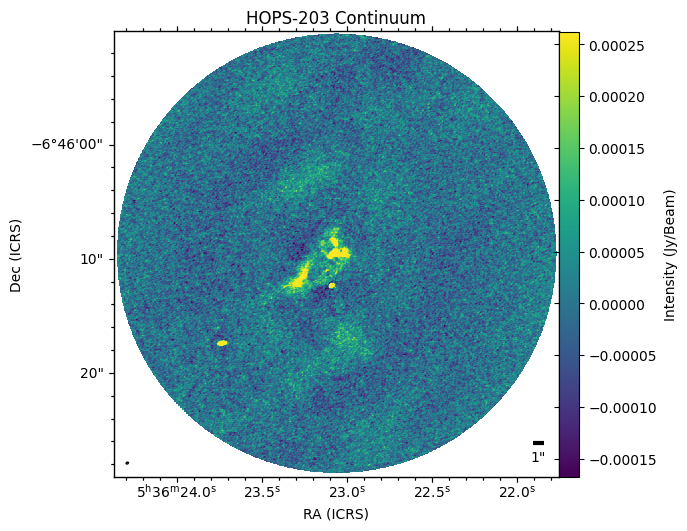

In [9]:
# extract center coords
center_ra = hdulist[0].header['OBSRA']
center_dec = hdulist[0].header['OBSDEC']

# set center and size of cutout
center = SkyCoord(center_ra, center_dec, unit=u.degree)
size = np.array([39, 39]) * u.arcsecond

fig = create_sub_fig(hdulist[0], center, size)
fig.set_title("HOPS-203 Continuum")
# fig.show_colorscale(cmap='viridis', stretch='log', vmid=-0.001)
fig.show_colorscale(cmap='viridis')
fig.savefig("../output/hops_203_cont_pretty.png")

## HOPS-203 Continuum Subfigures

INFO: Auto-setting vmin to -1.257e-03 [aplpy.core]
INFO: Auto-setting vmax to  1.304e-02 [aplpy.core]
INFO: Auto-setting vmin to -1.258e-03 [aplpy.core]
INFO: Auto-setting vmax to  1.304e-02 [aplpy.core]
INFO: Auto-setting vmin to -1.901e-03 [aplpy.core]
INFO: Auto-setting vmax to  1.900e-02 [aplpy.core]


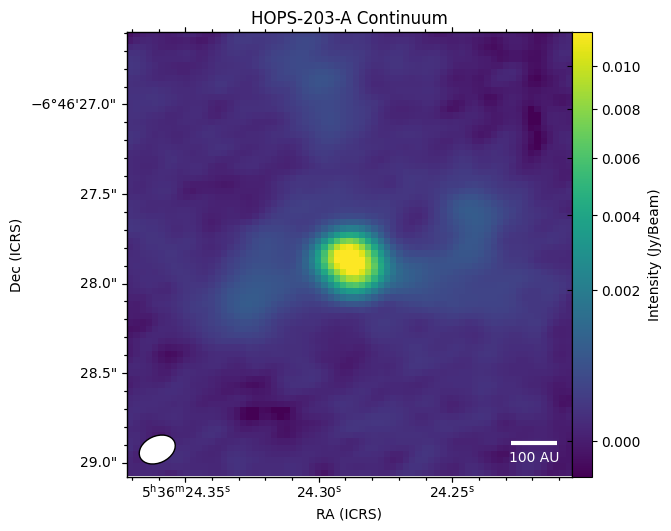

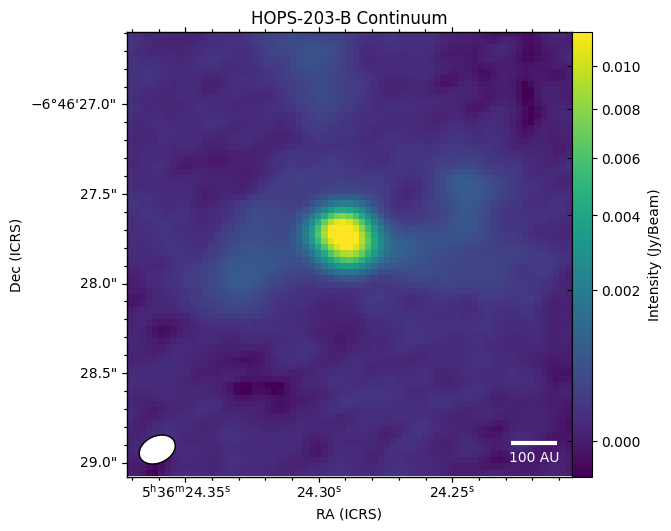

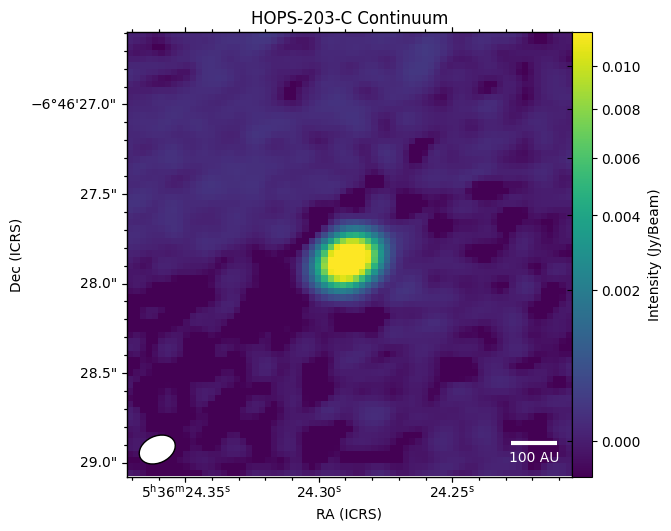

In [10]:
for _, row in target.iterrows():
    # set center and size of cutout
    center = SkyCoord(row['ra'], row['dec'], unit=u.degree)
    size = np.array([2.5,2.5]) * u.arcsecond

    # plot figure
    fig = create_sub_fig(hdu=hdulist[0], center=center, size=size, distance=row['dis'])
    fig.scalebar.set_color('white')
    fig.set_title(f"{row['source']} Continuum")
    fig.show_colorscale(cmap='viridis', stretch='sqrt', vmin=-7.5e-5, vmax=1.175e-2)
    fig.savefig(f"../output/{row['source']}_pretty.png")